## Audio Processing using Python

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa

In [2]:
audio_path = "audio.mp3"

In [3]:
y, sr = librosa.load(audio_path, sr=None)

In [4]:
y

array([1.3065408e-04, 1.2744215e-04, 3.9299979e-05, ..., 1.5634283e-03,
       1.8312822e-03, 1.7117229e-03], dtype=float32)

In [5]:
y.shape

(293280,)

In [6]:
y[:100]

array([ 1.30654080e-04,  1.27442152e-04,  3.92999791e-05, -1.05463245e-04,
       -5.58033062e-04, -1.03087479e-03, -1.13327592e-03, -1.12529518e-03,
       -1.11502386e-03, -9.74840892e-04, -7.69571343e-04, -6.83541119e-04,
       -6.92980713e-04, -6.27420726e-04, -8.25858908e-04, -1.11156621e-03,
       -1.13803823e-03, -1.27814978e-03, -1.45614927e-03, -1.49795960e-03,
       -1.95408170e-03, -2.35253060e-03, -2.11344287e-03, -1.99733139e-03,
       -1.97124551e-03, -1.76438177e-03, -1.64523558e-03, -1.56145287e-03,
       -1.54123851e-03, -1.79074344e-03, -1.82706816e-03, -1.62767537e-03,
       -1.54607464e-03, -1.28111371e-03, -1.14093209e-03, -1.07825303e-03,
       -9.80169745e-04, -9.95943905e-04, -1.06998370e-03, -1.19818852e-03,
       -1.16686779e-03, -1.19607581e-03, -1.46394060e-03, -1.59161107e-03,
       -1.58683769e-03, -1.74489967e-03, -1.39148056e-03, -1.12908706e-03,
       -1.36403670e-03, -1.14755670e-03, -1.40747381e-03, -1.82135717e-03,
       -1.84988417e-03, -

In [7]:
sr

16000

Text(0, 0.5, 'Amplitude')

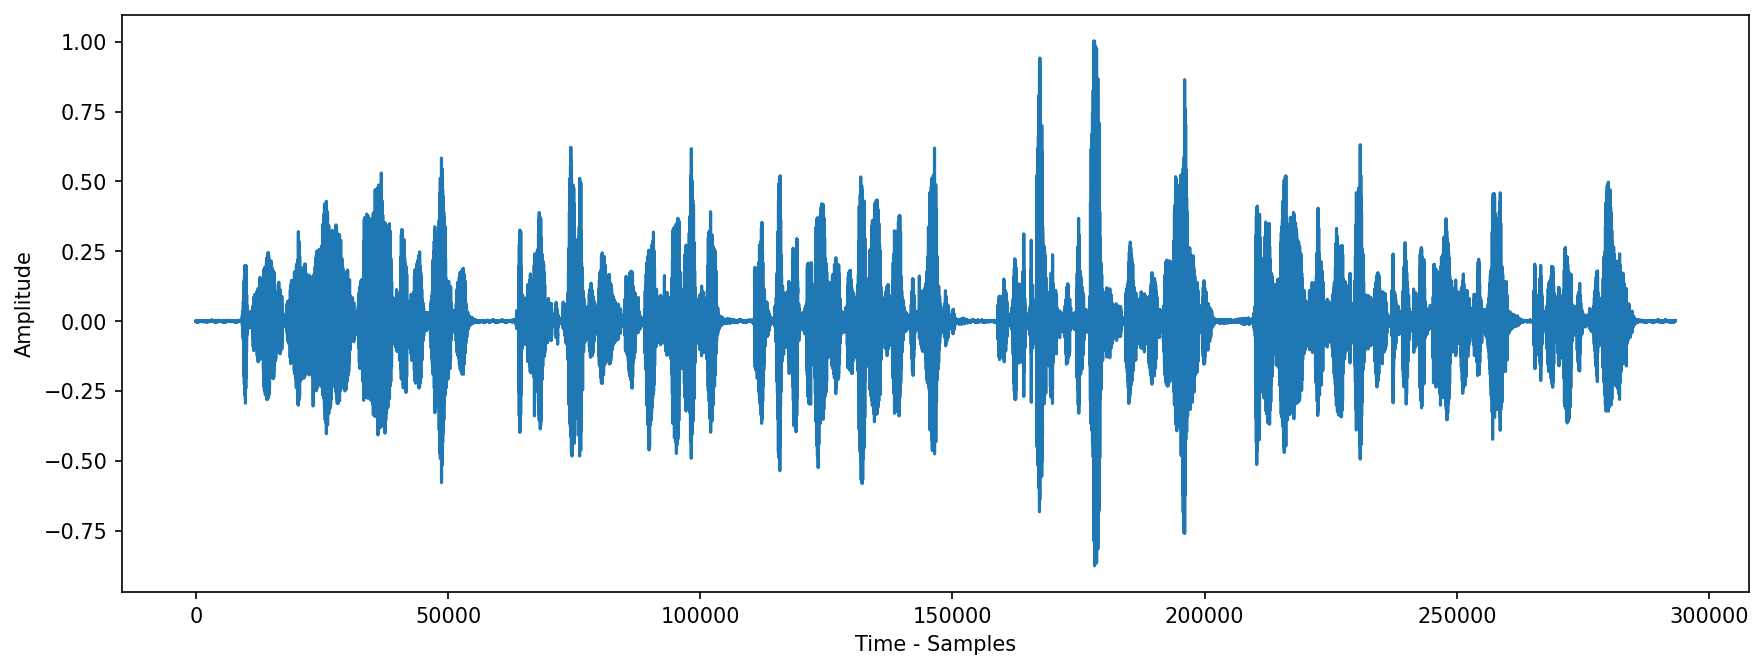

In [8]:
plt.figure(figsize=(14, 5), dpi=150)
plt.plot(y);
plt.xlabel("Time - Samples")
plt.ylabel("Amplitude")

### Dividing the number of data points in the sound by the sampling rate yields the total time of the audio

In [9]:
len(y) / sr

18.33

In [10]:
150000 / sr

9.375

In [11]:
from IPython.display import Audio

In [70]:
y[:100]

array([ 1.30654080e-04,  1.27442152e-04,  3.92999791e-05, -1.05463245e-04,
       -5.58033062e-04, -1.03087479e-03, -1.13327592e-03, -1.12529518e-03,
       -1.11502386e-03, -9.74840892e-04, -7.69571343e-04, -6.83541119e-04,
       -6.92980713e-04, -6.27420726e-04, -8.25858908e-04, -1.11156621e-03,
       -1.13803823e-03, -1.27814978e-03, -1.45614927e-03, -1.49795960e-03,
       -1.95408170e-03, -2.35253060e-03, -2.11344287e-03, -1.99733139e-03,
       -1.97124551e-03, -1.76438177e-03, -1.64523558e-03, -1.56145287e-03,
       -1.54123851e-03, -1.79074344e-03, -1.82706816e-03, -1.62767537e-03,
       -1.54607464e-03, -1.28111371e-03, -1.14093209e-03, -1.07825303e-03,
       -9.80169745e-04, -9.95943905e-04, -1.06998370e-03, -1.19818852e-03,
       -1.16686779e-03, -1.19607581e-03, -1.46394060e-03, -1.59161107e-03,
       -1.58683769e-03, -1.74489967e-03, -1.39148056e-03, -1.12908706e-03,
       -1.36403670e-03, -1.14755670e-03, -1.40747381e-03, -1.82135717e-03,
       -1.84988417e-03, -

In [71]:
Audio(data=y, rate=sr)

In [13]:
# DFT - Discrete Fourier Transform
window = np.hanning(len(y))
windowed_input = y * window
dft = np.fft.rfft(windowed_input)

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


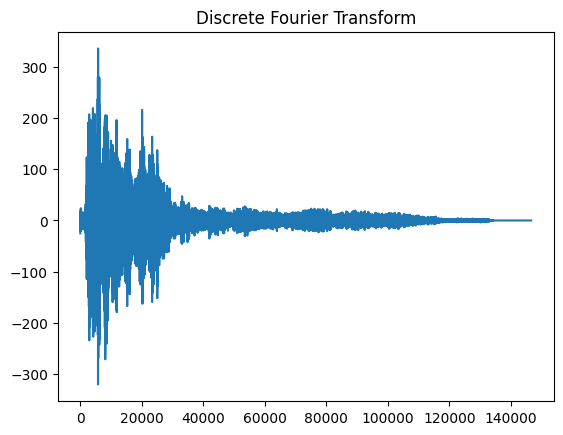

In [14]:
plt.plot(dft);
plt.title("Discrete Fourier Transform");

In [15]:
amplitude = np.abs(dft)

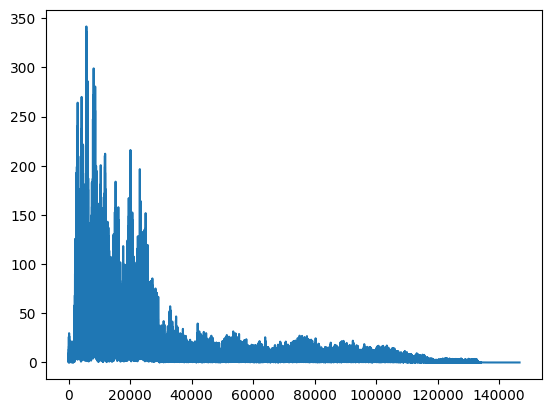

In [16]:
plt.plot(amplitude);

In [17]:
amplitude_db = librosa.amplitude_to_db(amplitude, ref=np.max)

In [18]:
frequency = librosa.fft_frequencies(sr=sr, n_fft=len(y))

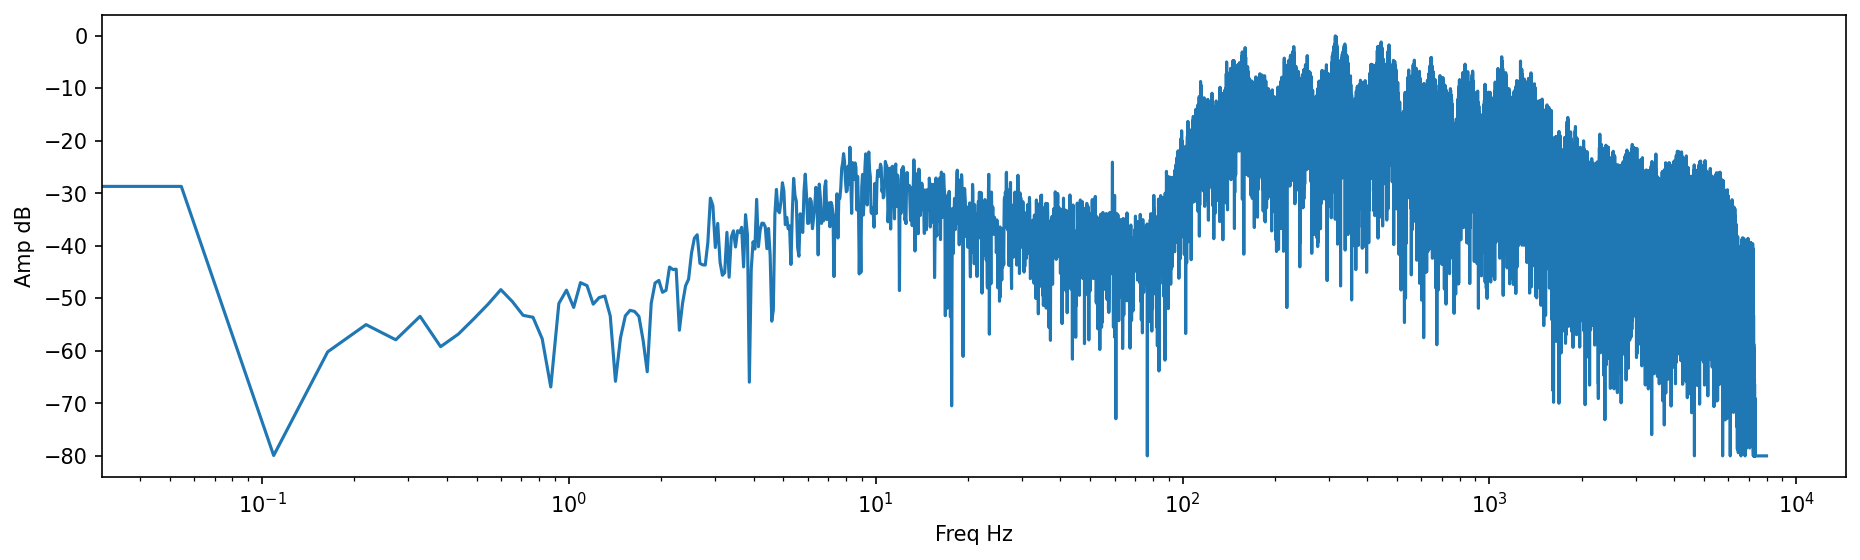

In [19]:
plt.figure(figsize=(15, 4), dpi=150)
plt.plot(frequency, amplitude_db)
plt.xlabel("Freq Hz")
plt.ylabel("Amp dB")
plt.xscale("log") # X scale logarithmic

In [20]:
D = librosa.stft(y)

D_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

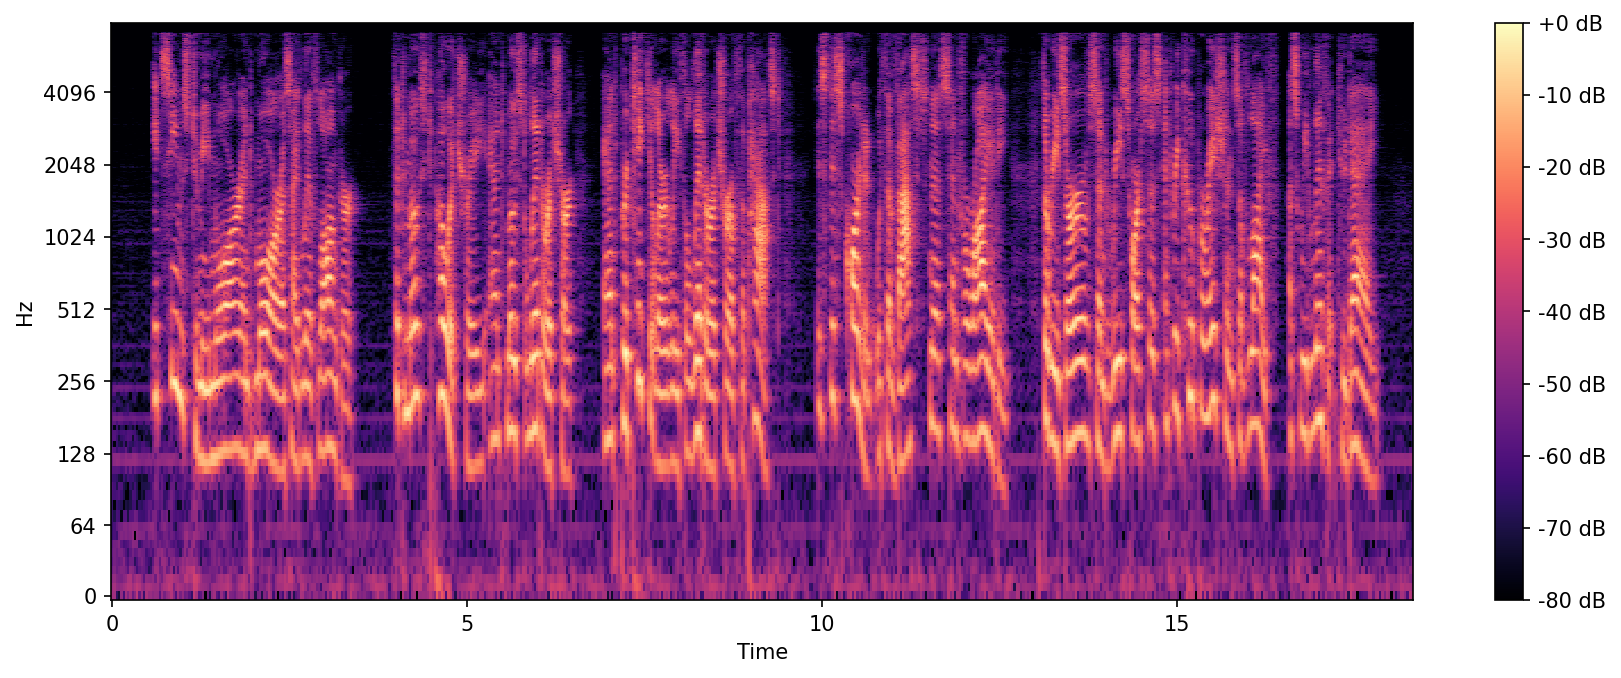

In [21]:
plt.figure(figsize=(14, 5), dpi=150)
librosa.display.specshow(D_db, sr=sr, x_axis="time", y_axis="log")
plt.colorbar(format="%+2.0f dB");

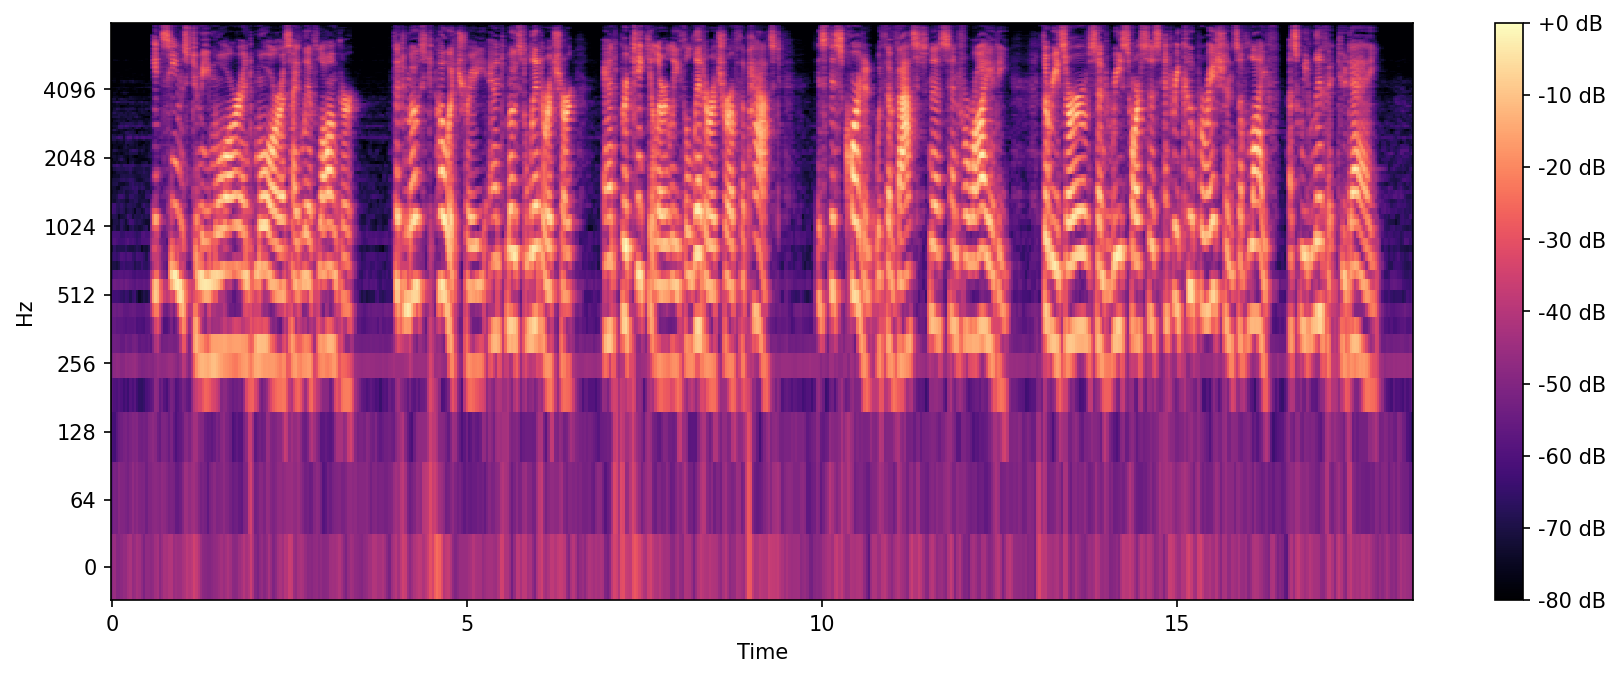

In [22]:
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
S_dB = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(14, 5), dpi=150)
librosa.display.specshow(S_dB, sr=sr, x_axis="time", y_axis="log", fmax=8000)
plt.colorbar(format="%+2.0f dB");

In [23]:
import torch, transformers, torchaudio
print(torch.__version__)
print(transformers.__version__)
print(torchaudio.__version__)

2.9.0+cu126
4.57.3
2.9.0+cu126


## Audio Classification

In [72]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("audio-classification", model="MIT/ast-finetuned-audioset-10-10-0.4593")

Device set to use cuda:0


In [24]:
from transformers import AutoFeatureExtractor, ASTForAudioClassification

In [25]:
import librosa

In [73]:
audio_path = "audio.mp3"

In [74]:
y, sr = librosa.load(audio_path, sr=None)

In [75]:
from IPython.display import Audio

In [76]:
Audio(data=audio_path)

In [30]:
sr

16000

In [77]:
feature_extractor = AutoFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")

In [79]:
result = feature_extractor(y, return_tensors="pt")

It is strongly recommended to pass the `sampling_rate` argument to `ASTFeatureExtractor()`. Failing to do so can result in silent errors that might be hard to debug.


In [80]:
result

{'input_values': tensor([[[-0.9321, -1.2776, -1.0237,  ..., -1.2776, -1.2776, -1.2776],
         [-0.8631, -1.2776, -0.9084,  ..., -1.2776, -1.2776, -1.2776],
         [-0.7948, -1.2612, -0.8844,  ..., -1.2776, -1.2776, -1.2776],
         ...,
         [-0.9018, -1.1873, -0.8105,  ..., -1.0920, -1.2776, -1.2776],
         [-0.6795, -1.0886, -0.7118,  ..., -0.9998, -1.2776, -1.2776],
         [-1.1374, -1.2776, -0.9605,  ..., -1.0743, -1.2776, -1.2776]]])}

In [81]:
model = ASTForAudioClassification.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")

In [82]:
result["input_values"]

tensor([[[-0.9321, -1.2776, -1.0237,  ..., -1.2776, -1.2776, -1.2776],
         [-0.8631, -1.2776, -0.9084,  ..., -1.2776, -1.2776, -1.2776],
         [-0.7948, -1.2612, -0.8844,  ..., -1.2776, -1.2776, -1.2776],
         ...,
         [-0.9018, -1.1873, -0.8105,  ..., -1.0920, -1.2776, -1.2776],
         [-0.6795, -1.0886, -0.7118,  ..., -0.9998, -1.2776, -1.2776],
         [-1.1374, -1.2776, -0.9605,  ..., -1.0743, -1.2776, -1.2776]]])

In [83]:
prediction_logits = model(result["input_values"]).logits

In [84]:
prediction_logits

tensor([[  1.7965,  -3.7954,  -5.4459,  -7.8613,  -4.8612,  -3.5137,  -9.6095,
          -3.7265, -10.1985,  -9.9395,  -9.3900, -10.6559, -12.1971, -11.3925,
         -10.0818,  -7.7840,  -8.1654,  -9.7118,  -9.5814,  -8.7985, -10.0107,
          -7.4823,  -9.6085,  -9.6653,  -8.3073, -10.1477,  -8.3053,  -9.1554,
         -11.2122, -11.6502, -10.8670,  -8.7019,  -9.5213, -10.3866, -10.9959,
         -12.4108,  -9.6888, -10.6453,  -9.5668, -10.0847,  -8.9650,  -5.4814,
          -8.3880,  -9.0063,  -5.0051,  -7.6081,  -6.6805,  -8.3295,  -6.3227,
          -8.1846,  -8.8153,  -8.3429,  -7.1892,  -7.7744,  -7.8176,  -6.9679,
         -10.9672,  -9.8152, -10.3226,  -8.6421,  -9.4470,  -7.6488,  -7.0414,
          -7.9217, -10.1883, -10.3939, -10.3756,  -9.6228, -11.4318,  -9.5012,
          -9.6716, -12.1192,  -5.3201,  -6.4119,  -7.1367,  -8.6594,  -9.1366,
         -11.7421,  -8.5112,  -9.4379,  -8.7637,  -6.6744,  -8.6104,  -7.6991,
          -7.1380,  -8.5310,  -8.8993,  -8.5767,  -8

In [85]:
predicted_class_ids = torch.argmax(prediction_logits, dim=-1).item()

In [86]:
predicted_class_ids

0

In [89]:
model.config.id2label

{0: 'Speech',
 1: 'Male speech, man speaking',
 2: 'Female speech, woman speaking',
 3: 'Child speech, kid speaking',
 4: 'Conversation',
 5: 'Narration, monologue',
 6: 'Babbling',
 7: 'Speech synthesizer',
 8: 'Shout',
 9: 'Bellow',
 10: 'Whoop',
 11: 'Yell',
 12: 'Battle cry',
 13: 'Children shouting',
 14: 'Screaming',
 15: 'Whispering',
 16: 'Laughter',
 17: 'Baby laughter',
 18: 'Giggle',
 19: 'Snicker',
 20: 'Belly laugh',
 21: 'Chuckle, chortle',
 22: 'Crying, sobbing',
 23: 'Baby cry, infant cry',
 24: 'Whimper',
 25: 'Wail, moan',
 26: 'Sigh',
 27: 'Singing',
 28: 'Choir',
 29: 'Yodeling',
 30: 'Chant',
 31: 'Mantra',
 32: 'Male singing',
 33: 'Female singing',
 34: 'Child singing',
 35: 'Synthetic singing',
 36: 'Rapping',
 37: 'Humming',
 38: 'Groan',
 39: 'Grunt',
 40: 'Whistling',
 41: 'Breathing',
 42: 'Wheeze',
 43: 'Snoring',
 44: 'Gasp',
 45: 'Pant',
 46: 'Snort',
 47: 'Cough',
 48: 'Throat clearing',
 49: 'Sneeze',
 50: 'Sniff',
 51: 'Run',
 52: 'Shuffle',
 53: 'Walk

In [40]:
model.config.id2label

{0: 'Speech',
 1: 'Male speech, man speaking',
 2: 'Female speech, woman speaking',
 3: 'Child speech, kid speaking',
 4: 'Conversation',
 5: 'Narration, monologue',
 6: 'Babbling',
 7: 'Speech synthesizer',
 8: 'Shout',
 9: 'Bellow',
 10: 'Whoop',
 11: 'Yell',
 12: 'Battle cry',
 13: 'Children shouting',
 14: 'Screaming',
 15: 'Whispering',
 16: 'Laughter',
 17: 'Baby laughter',
 18: 'Giggle',
 19: 'Snicker',
 20: 'Belly laugh',
 21: 'Chuckle, chortle',
 22: 'Crying, sobbing',
 23: 'Baby cry, infant cry',
 24: 'Whimper',
 25: 'Wail, moan',
 26: 'Sigh',
 27: 'Singing',
 28: 'Choir',
 29: 'Yodeling',
 30: 'Chant',
 31: 'Mantra',
 32: 'Male singing',
 33: 'Female singing',
 34: 'Child singing',
 35: 'Synthetic singing',
 36: 'Rapping',
 37: 'Humming',
 38: 'Groan',
 39: 'Grunt',
 40: 'Whistling',
 41: 'Breathing',
 42: 'Wheeze',
 43: 'Snoring',
 44: 'Gasp',
 45: 'Pant',
 46: 'Snort',
 47: 'Cough',
 48: 'Throat clearing',
 49: 'Sneeze',
 50: 'Sniff',
 51: 'Run',
 52: 'Shuffle',
 53: 'Walk

In [90]:
model.config.id2label[predicted_class_ids]

'Speech'

In [42]:
from transformers import pipeline

In [43]:
pipe = pipeline("audio-classification", model="MIT/ast-finetuned-audioset-10-10-0.4593")

Device set to use cuda:0


In [44]:
pipe.model

ASTForAudioClassification(
  (audio_spectrogram_transformer): ASTModel(
    (embeddings): ASTEmbeddings(
      (patch_embeddings): ASTPatchEmbeddings(
        (projection): Conv2d(1, 768, kernel_size=(16, 16), stride=(10, 10))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ASTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ASTLayer(
          (attention): ASTAttention(
            (attention): ASTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ASTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ASTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=T

## Converting Audio to text

## The largest dataset for audio files `LibriSpeech ASR corpus`

In [45]:
from transformers import pipeline

In [91]:
pipe = pipeline("automatic-speech-recognition")

No model was supplied, defaulted to facebook/wav2vec2-base-960h and revision 22aad52 (https://huggingface.co/facebook/wav2vec2-base-960h).
Using a pipeline without specifying a model name and revision in production is not recommended.
Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cuda:0


In [92]:
pipe

In [93]:
pipe("audio.mp3")

{'text': 'IT SEEMS TO ME MORE AND MORE AS I LIVE LONGER THAT MOST POETRY AND MOST LITERATURE AND PARTICULARLY THE LITERATURE OF THE PAST IS DISCORDANT WITH A VASTNESS AND VARIETY THE RESERVES AND RESOURCES AND RECUPERATIONS OF LIFE AS WE LIVE AT TO DAY'}

## Converting text to audio

In [95]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("text-to-speech", model="suno/bark-small")

Device set to use cuda:0


In [94]:
from transformers import pipeline
pipe = pipeline("text-to-speech")

No model was supplied, defaulted to suno/bark-small and revision 1dbd7a1 (https://huggingface.co/suno/bark-small).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cuda:0


In [102]:
text = "I am learning machine learning"

In [103]:
output = pipe(text)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:10000 for open-end generation.


In [104]:
output

{'audio': array([[0.01465335, 0.01761986, 0.02734685, ..., 0.00349378, 0.00421023,
         0.00458485]], dtype=float32),
 'sampling_rate': 24000}

In [105]:
output["audio"]

array([[0.01465335, 0.01761986, 0.02734685, ..., 0.00349378, 0.00421023,
        0.00458485]], dtype=float32)

In [106]:
output["sampling_rate"]

24000

In [107]:
import matplotlib.pyplot as plt

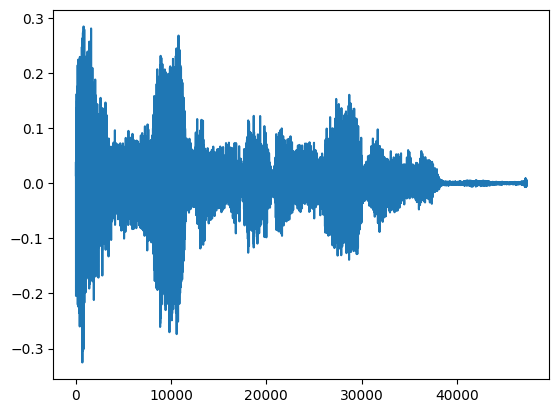

In [108]:
plt.plot(output["audio"][0]);

In [109]:
from IPython.display import Audio

In [110]:
text

'I am learning machine learning'

In [111]:
Audio(data=output["audio"], rate=output["sampling_rate"])

In [112]:
text = "I like coding in python"

In [113]:
output = pipe(text)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:10000 for open-end generation.


In [114]:
output

{'audio': array([[ 0.00152953,  0.00179542,  0.00184545, ...,  0.0027305 ,
          0.00361251, -0.00507926]], dtype=float32),
 'sampling_rate': 24000}

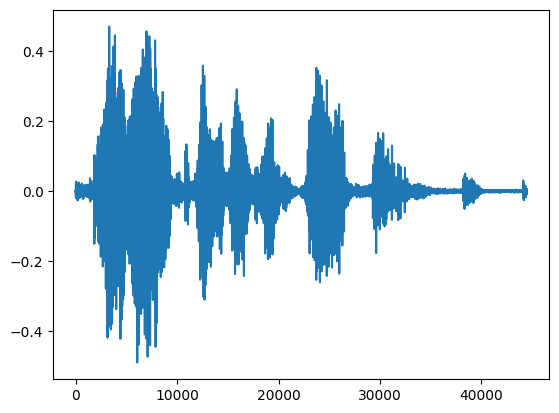

In [115]:
plt.plot(output["audio"][0])

In [116]:
Audio(data=output["audio"], rate=output["sampling_rate"])

In [65]:
from pydub import AudioSegment

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


In [66]:
text = "I like coding in python"
output = pipe(text)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:10000 for open-end generation.


In [117]:
audio_seg = AudioSegment(output["audio"].tobytes(),
                         frame_rate=output["sampling_rate"],
                         sample_width=output["audio"].dtype.itemsize,
                         channels=1)

In [118]:
audio_seg.export("tts_example.mp3", format="mp3")

<_io.BufferedRandom name='tts_example.mp3'>